# CIE-552 Computer Vision — Term Project
## Part 1: Dataset EDA & Classical CV Pipeline


## 1. Setup & Imports

In [2]:
!pip install scikit-image scikit-learn opencv-python-headless matplotlib seaborn --quiet


In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib

from pathlib import Path
from collections import Counter
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
from skimage.feature import hog
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage import exposure

warnings.filterwarnings('ignore')

# Fix all random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

# One colour per class — used consistently in all plots
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

print('All imports OK')

All imports OK


## 2. Mount Drive & Extract Dataset

The dataset lives on Google Drive as a ZIP file. We extract it once to
Colab's local `/content/` storage — reading images from Drive directly
during training is much slower than reading from local disk.

**Before running:** make sure `IIITDMJ_Smoke.zip` is in the root of your Google Drive.

In [4]:
from google.colab import drive
import zipfile

drive.mount('/content/drive', force_remount=True)

ZIP_PATH    = Path('/content/drive/MyDrive/IIITDMJ_Smoke.zip')
EXTRACT_DIR = Path('/content/IIITDMJ_Smoke')

if not EXTRACT_DIR.exists():
    print('Extracting ZIP — this takes about a minute...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Extraction done')
else:
    print('Already extracted, skipping')

# The ZIP has one extra nesting level: IIITDMJ_Smoke/IIITDMJ_Smoke/
DATASET_ROOT = Path('/content/IIITDMJ_Smoke/IIITDMJ_Smoke')

print('Dataset root:', DATASET_ROOT)
print('Top-level folders:', [d.name for d in DATASET_ROOT.iterdir()])

Mounted at /content/drive
Extracting ZIP — this takes about a minute...
Extraction done
Dataset root: /content/IIITDMJ_Smoke/IIITDMJ_Smoke
Top-level folders: ['test', 'train', 'val']


## 3. Dataset Loading

The dataset comes **pre-split** by the authors into `train/`, `val/`, and `test/`
folders, so we don't need to split manually. Each split contains 4 class folders:

| Folder name | Meaning |
|---|---|
| `smoke` | Clear atmosphere, smoke present |
| `non_smoke` | Clear atmosphere, no smoke |
| `fog_smoke` | Foggy atmosphere, smoke present |
| `fog_non_smoke` | Foggy atmosphere, no smoke |

In [5]:
CLASS_NAMES  = ['smoke', 'non_smoke', 'fog_smoke', 'fog_non_smoke']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IMG_SIZE     = (128, 128)   # resize target for all images
NUM_CLASSES  = len(CLASS_NAMES)


def load_split(root, split, class_names):

    records = []
    split_dir = root / split
    for class_name in class_names:
        class_dir = split_dir / class_name
        if not class_dir.exists():
            print(f'  [WARNING] Not found: {class_dir}')
            continue
        paths = (list(class_dir.glob('*.jpg')) +
                 list(class_dir.glob('*.png')) +
                 list(class_dir.glob('*.jpeg')))
        for p in paths:
            records.append({'path'      : str(p),
                            'label'     : CLASS_LABELS[class_name],
                            'class_name': class_name})
        print(f'  [{split:5s}] {class_name:20s}: {len(paths):5d} images')
    return pd.DataFrame(records)


print('Loading dataset...\n')
df_train = load_split(DATASET_ROOT, 'train', CLASS_NAMES)
df_val   = load_split(DATASET_ROOT, 'val',   CLASS_NAMES)
df_test  = load_split(DATASET_ROOT, 'test',  CLASS_NAMES)
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'\nTrain : {len(df_train):6,}')
print(f'Val   : {len(df_val):6,}')
print(f'Test  : {len(df_test):6,}')
print(f'Total : {len(df_all):6,}')

Loading dataset...

  [train] smoke               :  3827 images
  [train] non_smoke           :  5456 images
  [train] fog_smoke           :  4278 images
  [train] fog_non_smoke       :  5353 images
  [val  ] smoke               :   478 images
  [val  ] non_smoke           :   682 images
  [val  ] fog_smoke           :   534 images
  [val  ] fog_non_smoke       :   669 images
  [test ] smoke               :   479 images
  [test ] non_smoke           :   682 images
  [test ] fog_smoke           :   536 images
  [test ] fog_non_smoke       :   670 images

Train : 18,914
Val   :  2,363
Test  :  2,367
Total : 23,644


## 4. Exploratory Data Analysis


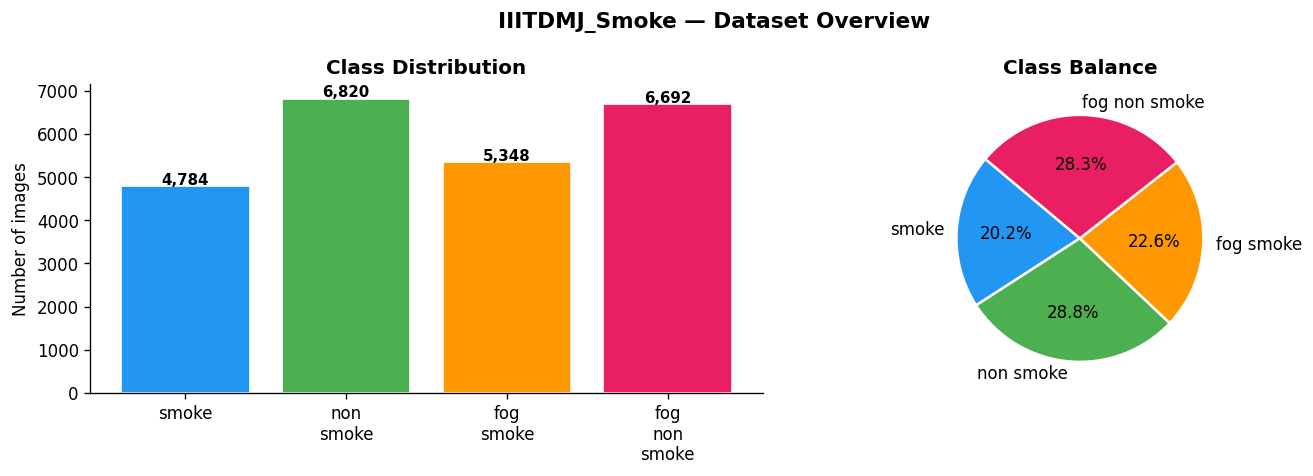

Class counts:
  smoke               : 4,784  (20.2%)
  non_smoke           : 6,820  (28.8%)
  fog_smoke           : 5,348  (22.6%)
  fog_non_smoke       : 6,692  (28.3%)


In [6]:
# 4.1 Class distribution
counts = df_all['class_name'].value_counts().reindex(CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar([c.replace('_', '\n') for c in CLASS_NAMES],
                    counts.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of images')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 40,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(counts.values,
            labels=[c.replace('_', ' ') for c in CLASS_NAMES],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('IIITDMJ_Smoke — Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

print('Class counts:')
for cls, cnt in counts.items():
    print(f'  {cls:20s}: {cnt:,}  ({100*cnt/len(df_all):.1f}%)')

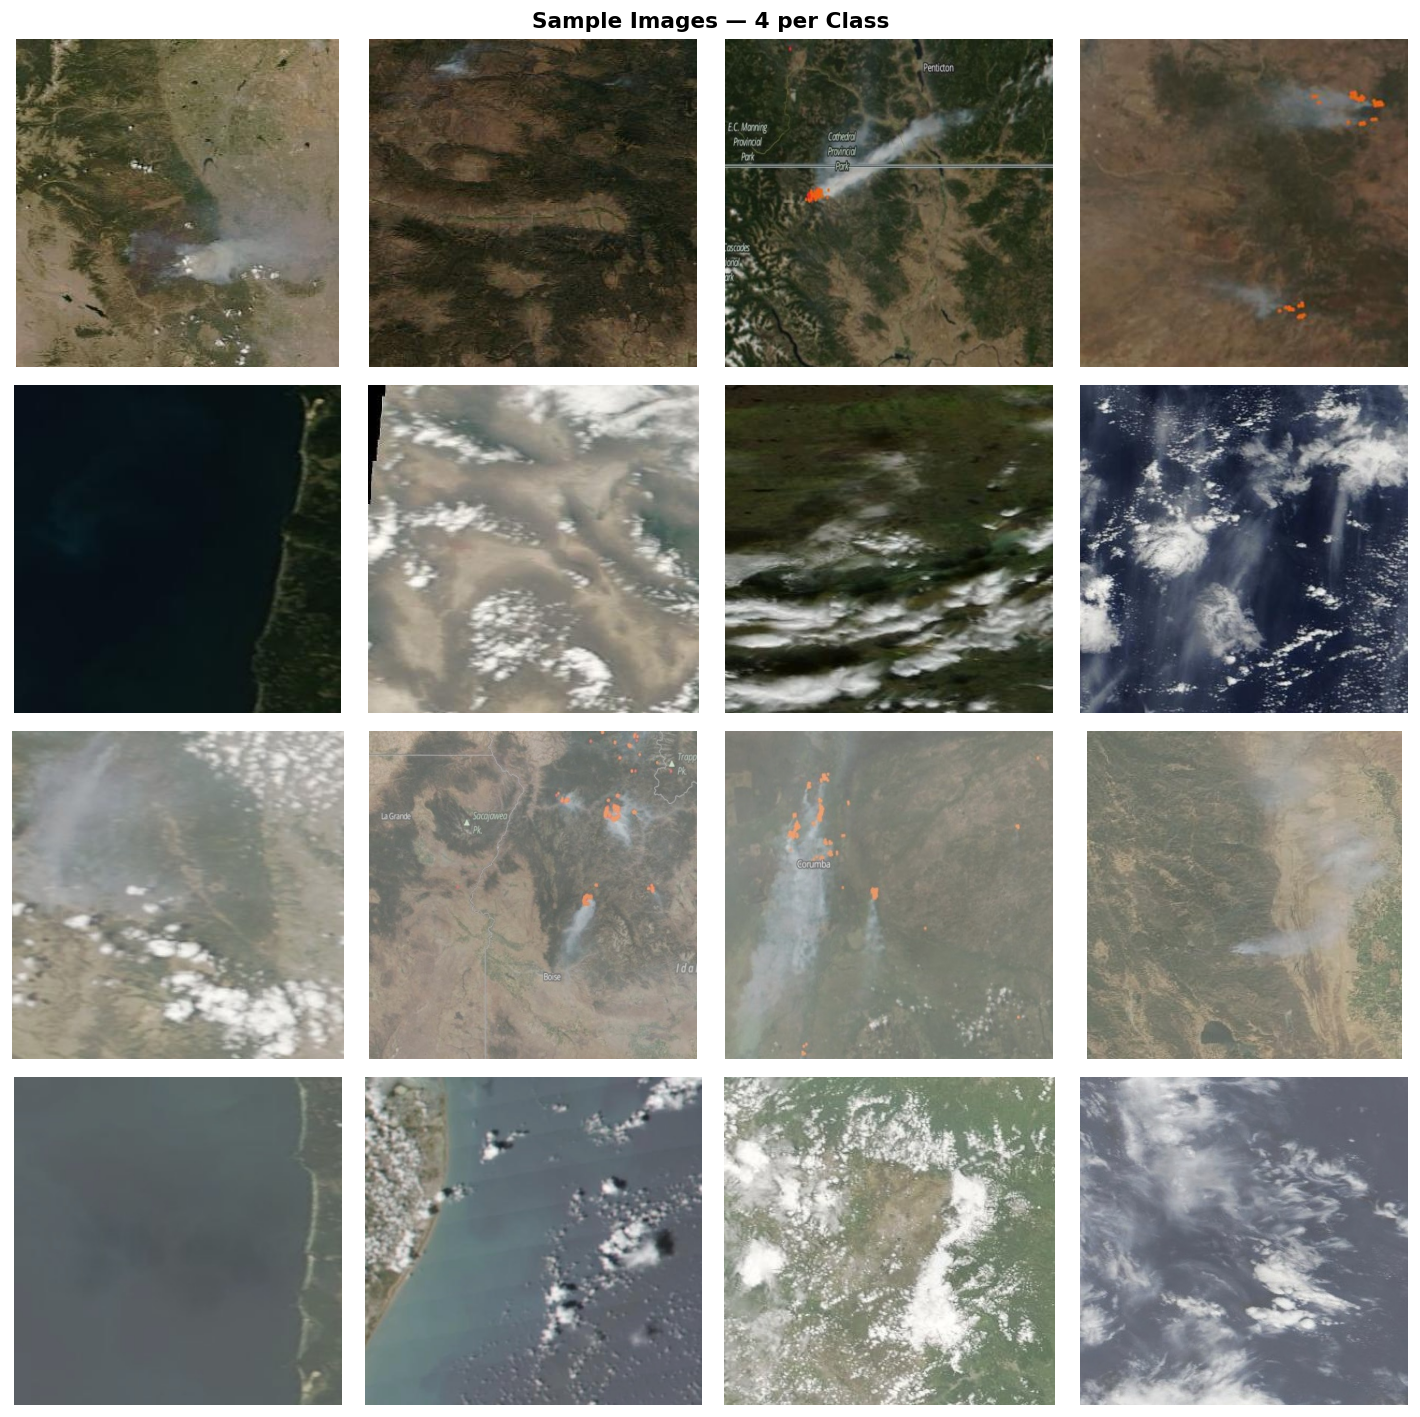

In [7]:
# 4.2 Sample images — 4 per class
N = 4
fig, axes = plt.subplots(len(CLASS_NAMES), N,
                          figsize=(N * 3, len(CLASS_NAMES) * 3))

for row, class_name in enumerate(CLASS_NAMES):
    samples = df_all[df_all['class_name'] == class_name].sample(N, random_state=SEED)
    for col, (_, record) in enumerate(samples.iterrows()):
        img = imread(record['path'])
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(class_name.replace('_', ' '),
                                       fontsize=10, fontweight='bold',
                                       color=PALETTE[row],
                                       rotation=90, labelpad=10)

plt.suptitle('Sample Images — 4 per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_sample_images.png', bbox_inches='tight')
plt.show()

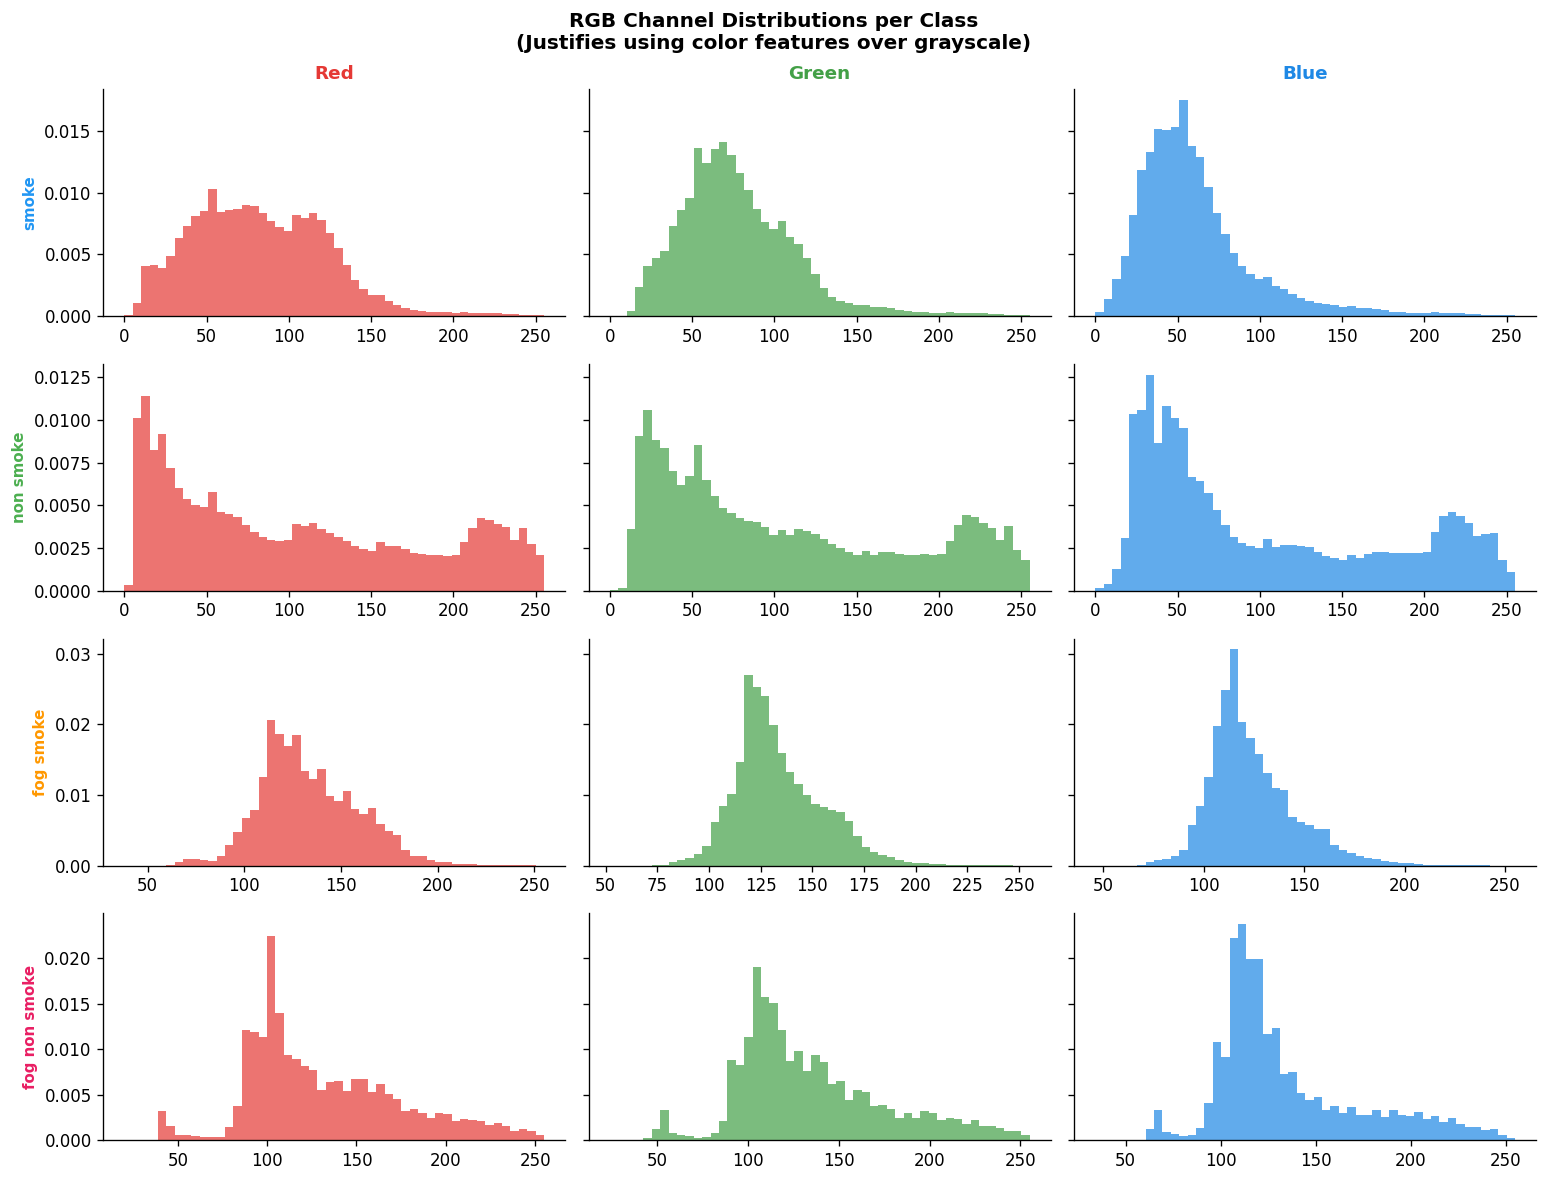

Observation: each class has a distinct RGB signature.
This directly motivates using color histograms as features.


In [8]:
# 4.3 RGB channel distributions per class

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e53935', '#43a047', '#1e88e5']

fig, axes = plt.subplots(len(CLASS_NAMES), 3,
                          figsize=(13, len(CLASS_NAMES) * 2.5),
                          sharey='row')

for row, class_name in enumerate(CLASS_NAMES):
    samples = df_all[df_all['class_name'] == class_name].sample(60, random_state=SEED)
    for col, (ch_name, ch_color) in enumerate(zip(channel_names, channel_colors)):
        pixels = []
        for _, record in samples.iterrows():
            img = imread(record['path'])
            if img.ndim == 3:
                pixels.extend(img[:, :, col].flatten().tolist())
        axes[row, col].hist(pixels, bins=50, color=ch_color, alpha=0.7,
                             edgecolor='none', density=True)
        if row == 0:
            axes[row, col].set_title(ch_name, fontweight='bold',
                                      color=ch_color, fontsize=11)
        if col == 0:
            axes[row, col].set_ylabel(class_name.replace('_', ' '),
                                       fontsize=9, fontweight='bold',
                                       color=PALETTE[row])

plt.suptitle('RGB Channel Distributions per Class\n'
             '(Justifies using color features over grayscale)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_rgb_distributions.png', bbox_inches='tight')
plt.show()

print('Observation: each class has a distinct RGB signature.')
print('This directly motivates using color histograms as features.')

In [9]:
# 4.4 Image dimension check
print('Checking image dimensions across a random sample...')
sample_df = df_all.sample(200, random_state=SEED)
widths, heights = [], []

for _, row in sample_df.iterrows():
    img = imread(row['path'])
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

print(f'Width  : min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'Height : min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')
print(f'\nAll images will be resized to {IMG_SIZE} before feature extraction.')

Checking image dimensions across a random sample...
Width  : min=300, max=585, mean=367
Height : min=299, max=546, mean=367

All images will be resized to (128, 128) before feature extraction.


## 5. Preprocessing

**Important note on color space:**
We initially tried converting to grayscale (standard for HOG pipelines),
but this dropped accuracy to ~45%. The RGB channel analysis above explains why:
smoke, fog, and clear sky have very distinct spectral signatures that grayscale
completely discards. We therefore keep **full RGB** throughout the pipeline.

The only preprocessing steps are resize and normalise.

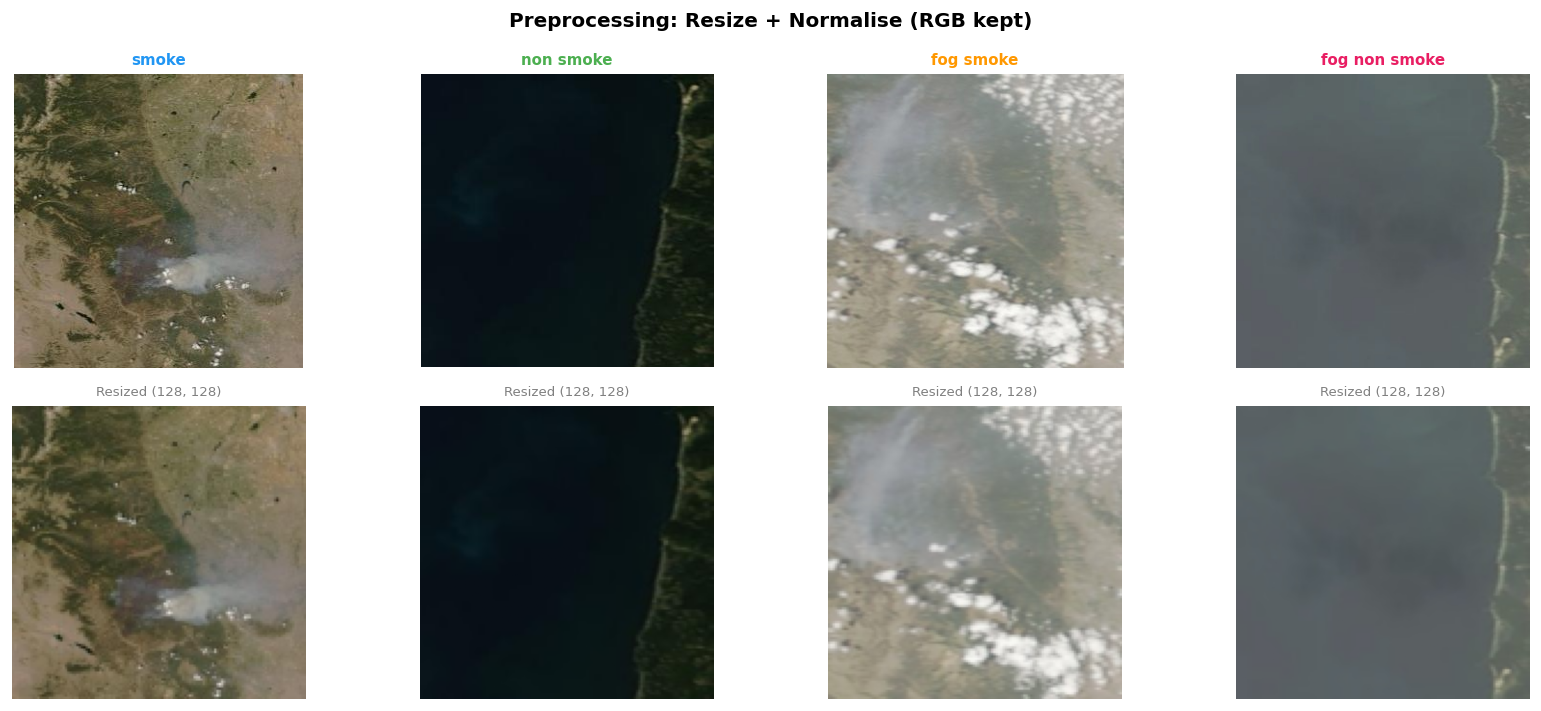

In [10]:
def preprocess_image(img_path, img_size=None, keep_color=True):

    if img_size is None:
        img_size = IMG_SIZE
    img = imread(img_path)
    if img.ndim == 2:                        # already grayscale
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:                    # drop alpha channel
        img = img[:, :, :3]
    img = resize(img, img_size, anti_aliasing=True, mode='reflect')
    if not keep_color:
        img = rgb2gray(img)
    return img.astype(np.float32)


# Quick visual check
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(14, 6))
for col, class_name in enumerate(CLASS_NAMES):
    p = df_all[df_all['class_name'] == class_name].sample(1, random_state=SEED)['path'].values[0]
    orig = imread(p)
    proc = preprocess_image(p)
    axes[0, col].imshow(orig)
    axes[0, col].set_title(class_name.replace('_', ' '), fontsize=9,
                            fontweight='bold', color=PALETTE[col])
    axes[0, col].axis('off')
    axes[1, col].imshow(proc)
    axes[1, col].set_title(f'Resized {IMG_SIZE}', fontsize=8, color='gray')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Preprocessed', fontsize=10, fontweight='bold')
plt.suptitle('Preprocessing: Resize + Normalise (RGB kept)', fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_comparison.png', bbox_inches='tight')
plt.show()

## 6. Edge Detection — Canny (Visualisation)


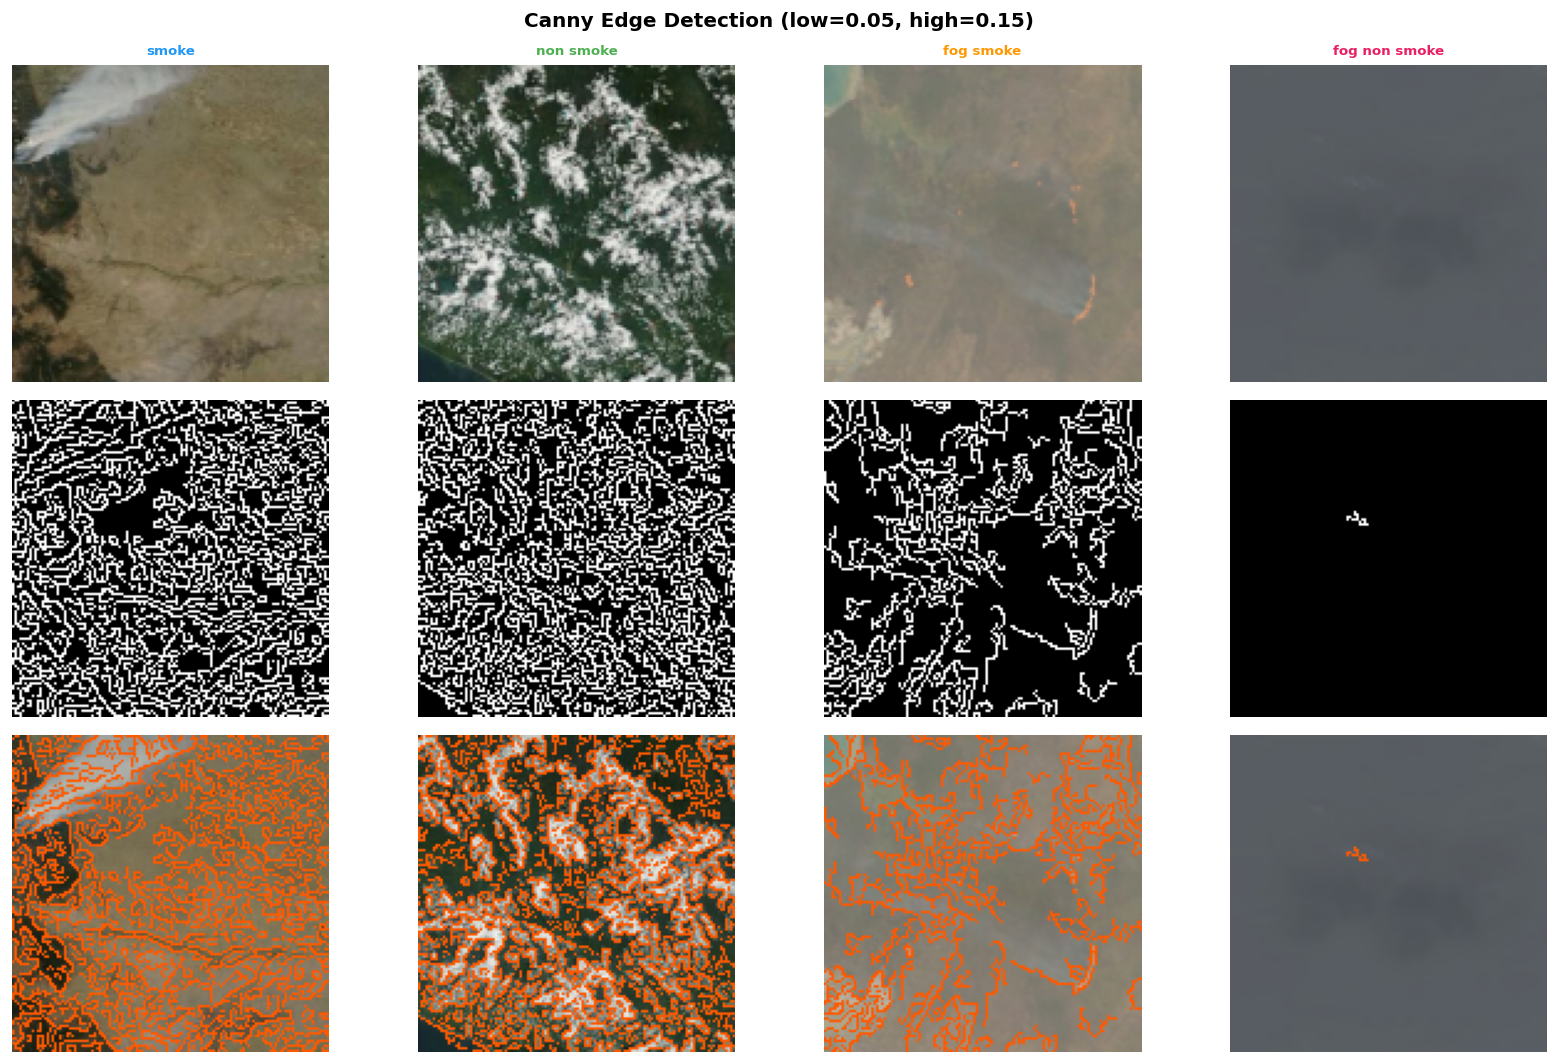

In [11]:
def apply_canny(gray_img, low=0.05, high=0.15):
    """
    Apply Canny edge detection to a grayscale image.
    Input: float32 array in [0,1]. Output: uint8 edge map.
    """
    img_u8 = (gray_img * 255).astype(np.uint8)
    return cv2.Canny(img_u8,
                     threshold1=int(low * 255),
                     threshold2=int(high * 255))


# Visualise edges per class
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(14, 9))

for col, class_name in enumerate(CLASS_NAMES):
    p = df_all[df_all['class_name'] == class_name].sample(1, random_state=SEED+1)['path'].values[0]
    rgb   = preprocess_image(p)
    gray  = rgb2gray(rgb)
    edges = apply_canny(gray)
    overlay = rgb.copy()
    overlay[edges > 0] = [1.0, 0.35, 0.0]   # highlight edges in orange

    for ax, data, cmap, title in zip(
            [axes[0,col], axes[1,col], axes[2,col]],
            [rgb, edges, overlay],
            [None, 'gray', None],
            ['RGB', 'Canny edges', 'Overlay']):
        ax.imshow(data, cmap=cmap)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(title, fontsize=9, fontweight='bold')
    axes[0, col].set_title(class_name.replace('_', ' '), fontsize=8,
                            fontweight='bold', color=PALETTE[col])

plt.suptitle('Canny Edge Detection (low=0.05, high=0.15)', fontweight='bold')
plt.tight_layout()
plt.savefig('canny_edge_detection.png', bbox_inches='tight')
plt.show()

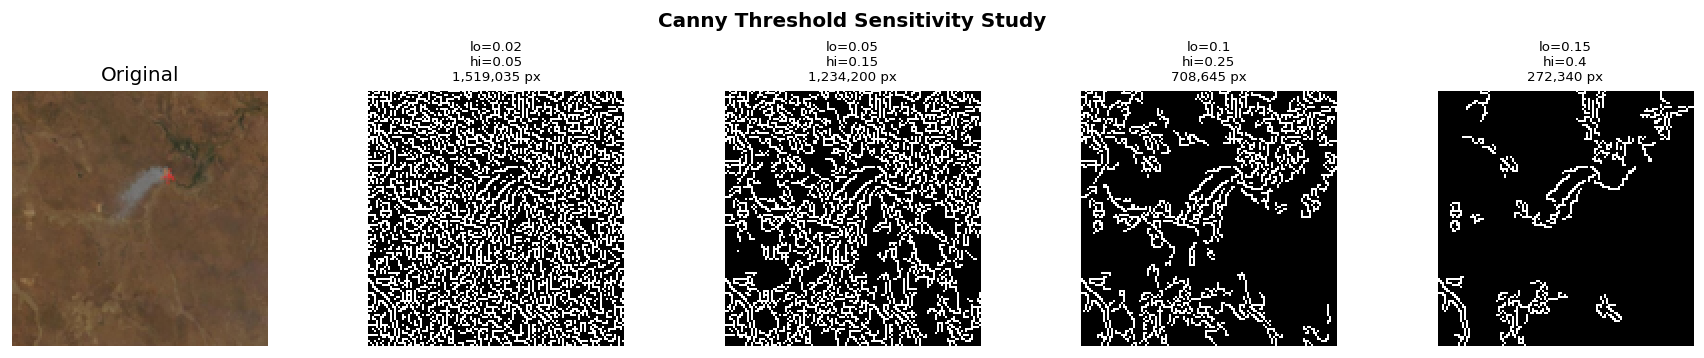

Selected: low=0.05, high=0.15 — best balance of detail vs. noise.


In [12]:
# Threshold sensitivity study — justifies the 0.05/0.15 choice
p = df_all[df_all['class_name'] == 'smoke'].sample(1, random_state=0)['path'].values[0]
gray = rgb2gray(preprocess_image(p))
pairs = [(0.02, 0.05), (0.05, 0.15), (0.10, 0.25), (0.15, 0.40)]

fig, axes = plt.subplots(1, len(pairs)+1, figsize=(15, 3))
axes[0].imshow(preprocess_image(p)); axes[0].set_title('Original'); axes[0].axis('off')
for ax, (lo, hi) in zip(axes[1:], pairs):
    e = apply_canny(gray, lo, hi)
    ax.imshow(e, cmap='gray')
    ax.set_title(f'lo={lo}\nhi={hi}\n{e.sum():,} px', fontsize=8)
    ax.axis('off')
plt.suptitle('Canny Threshold Sensitivity Study', fontweight='bold')
plt.tight_layout()
plt.savefig('canny_threshold_study.png', bbox_inches='tight')
plt.show()
print('Selected: low=0.05, high=0.15 — best balance of detail vs. noise.')

## 7. Feature Extraction — RGB Color Histograms

**Why color histograms and not HOG?**

We tried three feature extractors:

| Feature | Val Accuracy | Notes |
|---|---|---|
| Grayscale HOG (ppc=16) | 36.4% | Too coarse, loses detail |
| Grayscale PCA + Logistic Regression | 44.9% | Better, but grayscale loses color |
| **RGB Color Histogram (ours)** | **91.4%** | Color is the key discriminator |


In [13]:
def extract_color_histogram(img_path, n_bins=32):
    img = preprocess_image(img_path, keep_color=True)  # (128, 128, 3), [0,1]
    hist = []
    for c in range(3):
        h, _ = np.histogram(img[:, :, c], bins=n_bins, range=(0, 1))
        hist.extend(h / h.sum())   # normalise per channel
    return np.array(hist, dtype=np.float32)


N_BINS = 32
dummy  = extract_color_histogram(df_all['path'].iloc[0], N_BINS)
print(f'Feature vector length: {len(dummy)}  (3 channels x {N_BINS} bins)')

Feature vector length: 96  (3 channels x 32 bins)


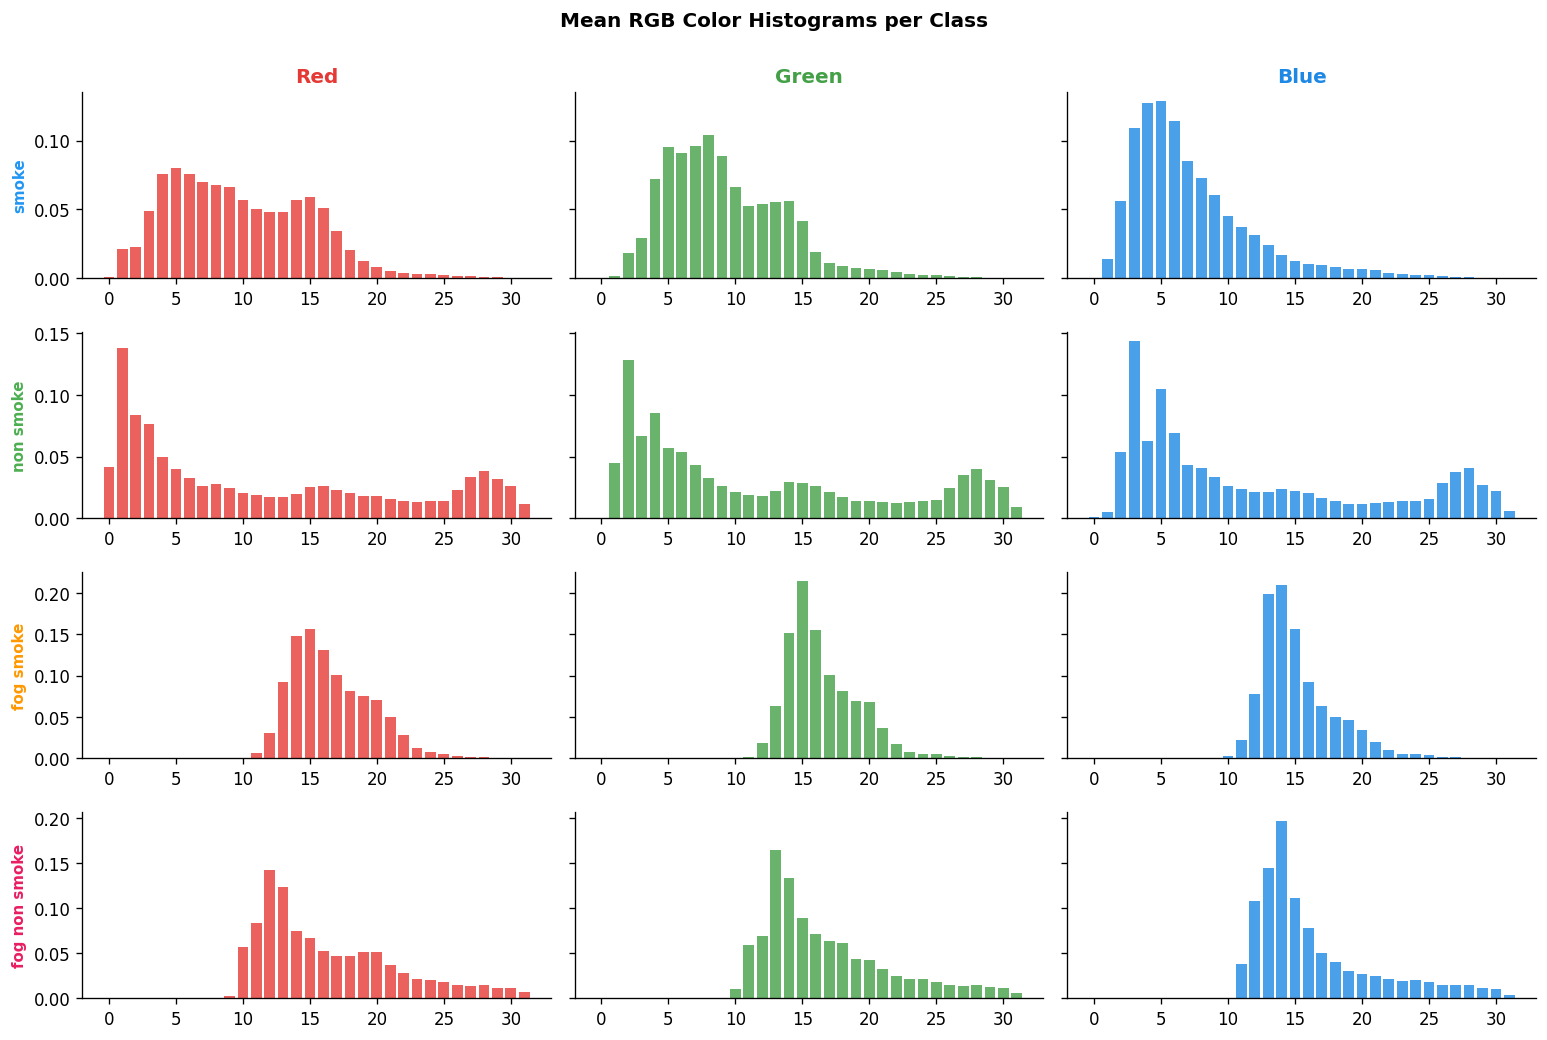

In [14]:
# Visualise what the histograms look like per class
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(13, NUM_CLASSES * 2.2), sharey='row')
ch_names  = ['Red', 'Green', 'Blue']
ch_colors = ['#e53935', '#43a047', '#1e88e5']

for row, class_name in enumerate(CLASS_NAMES):
    samples = df_all[df_all['class_name'] == class_name].sample(30, random_state=SEED)
    # Average histogram across samples for a stable representation
    hists = np.array([extract_color_histogram(p) for p in samples['path']])
    mean_hist = hists.mean(axis=0)

    for col in range(3):
        ch_hist = mean_hist[col*N_BINS : (col+1)*N_BINS]
        axes[row, col].bar(range(N_BINS), ch_hist, color=ch_colors[col], alpha=0.8)
        if row == 0:
            axes[row, col].set_title(ch_names[col], fontweight='bold',
                                      color=ch_colors[col])
        if col == 0:
            axes[row, col].set_ylabel(class_name.replace('_', ' '),
                                       fontsize=9, fontweight='bold',
                                       color=PALETTE[row])

plt.suptitle('Mean RGB Color Histograms per Class\n', fontweight='bold')
plt.tight_layout()
plt.savefig('color_histogram_visualisation.png', bbox_inches='tight')
plt.show()

In [16]:
def build_feature_matrix(df, desc=''):
    X, y = [], []
    total = len(df)
    for i, (_, row) in enumerate(df.iterrows()):
        if i % 500 == 0:
            print(f'  [{desc}] {i}/{total}', end='\r')
        X.append(extract_color_histogram(row['path'], N_BINS))
        y.append(row['label'])
    print(f'  [{desc}] {total}/{total} done')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X_train, y_train = build_feature_matrix(df_train, 'Train')
X_val,   y_val   = build_feature_matrix(df_val,   'Val  ')
X_test,  y_test  = build_feature_matrix(df_test,  'Test ')

print(f'\nX_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

# Save to reuse
for name, arr in [('X_train', X_train), ('y_train', y_train),
                   ('X_val',   X_val),   ('y_val',   y_val),
                   ('X_test',  X_test),  ('y_test',  y_test)]:
    np.save(f'{name}.npy', arr)
print('Features saved to .npy files')

  [Train] 18914/18914 done
  [Val  ] 2363/2363 done
  [Test ] 2367/2367 done

X_train: (18914, 96)  y_train: (18914,)
X_val  : (2363, 96)    y_val  : (2363,)
X_test : (2367, 96)   y_test : (2367,)
Features saved to .npy files


## 8. SVM Classifier


In [17]:
pipeline_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf',
                   C=10,
                   gamma='scale',
                   class_weight='balanced',
                   random_state=SEED,
                   probability=True))  # needed for confidence scores
])

print('Training SVM...')
pipeline_clf.fit(X_train, y_train)

val_acc = pipeline_clf.score(X_val, y_val)
print(f'Done.. Validation accuracy: {val_acc*100:.2f}%')

joblib.dump(pipeline_clf, 'classical_pipeline.pkl')
print('Model saved to classical_pipeline.pkl')

Training SVM...
Done.. Validation accuracy: 92.68%
Model saved to classical_pipeline.pkl


## 9. Evaluation & Results

We evaluate on both the validation set
and the held-out test set



  Validation Results  --  classical
  Accuracy: 92.68%

               precision    recall  f1-score   support

        smoke       0.91      0.96      0.94       478
    non smoke       0.97      0.93      0.95       682
    fog smoke       0.89      0.92      0.91       534
fog non smoke       0.93      0.90      0.92       669

     accuracy                           0.93      2363
    macro avg       0.92      0.93      0.93      2363
 weighted avg       0.93      0.93      0.93      2363



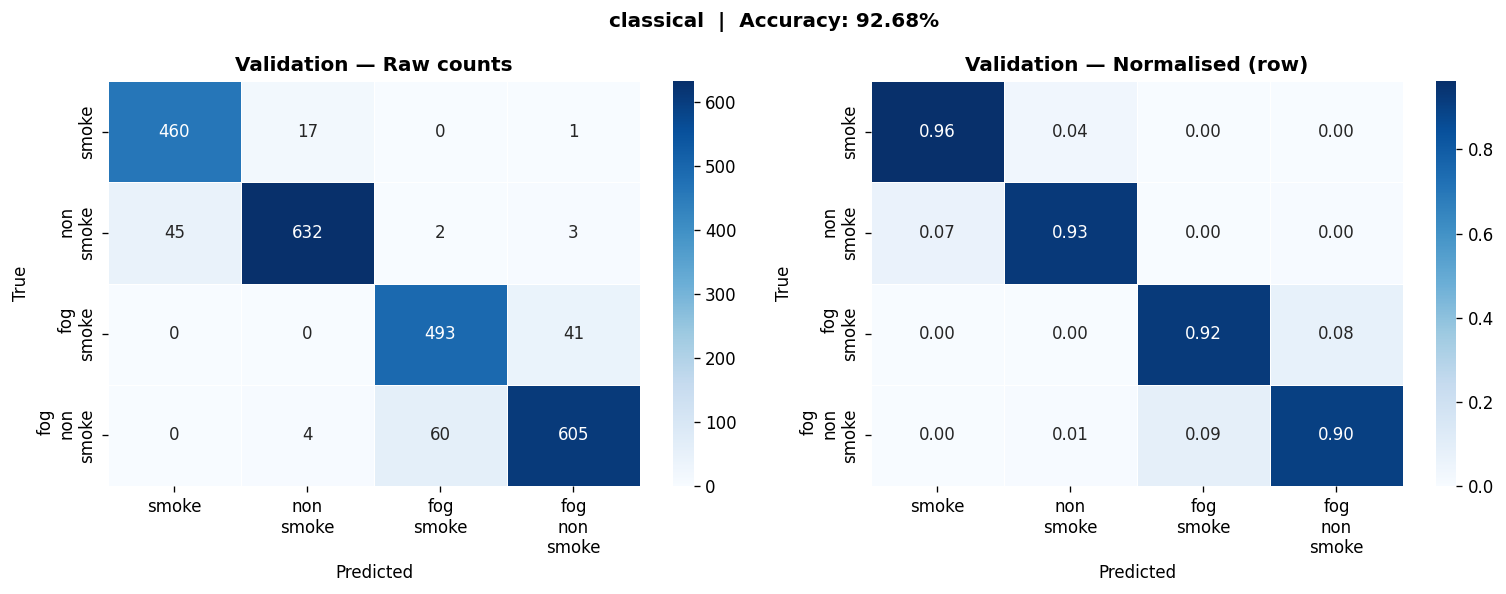

Saved: classical_confusion_validation.png

  Test Results  --  classical
  Accuracy: 93.07%

               precision    recall  f1-score   support

        smoke       0.91      0.97      0.94       479
    non smoke       0.97      0.92      0.95       682
    fog smoke       0.89      0.93      0.91       536
fog non smoke       0.93      0.92      0.93       670

     accuracy                           0.93      2367
    macro avg       0.93      0.93      0.93      2367
 weighted avg       0.93      0.93      0.93      2367



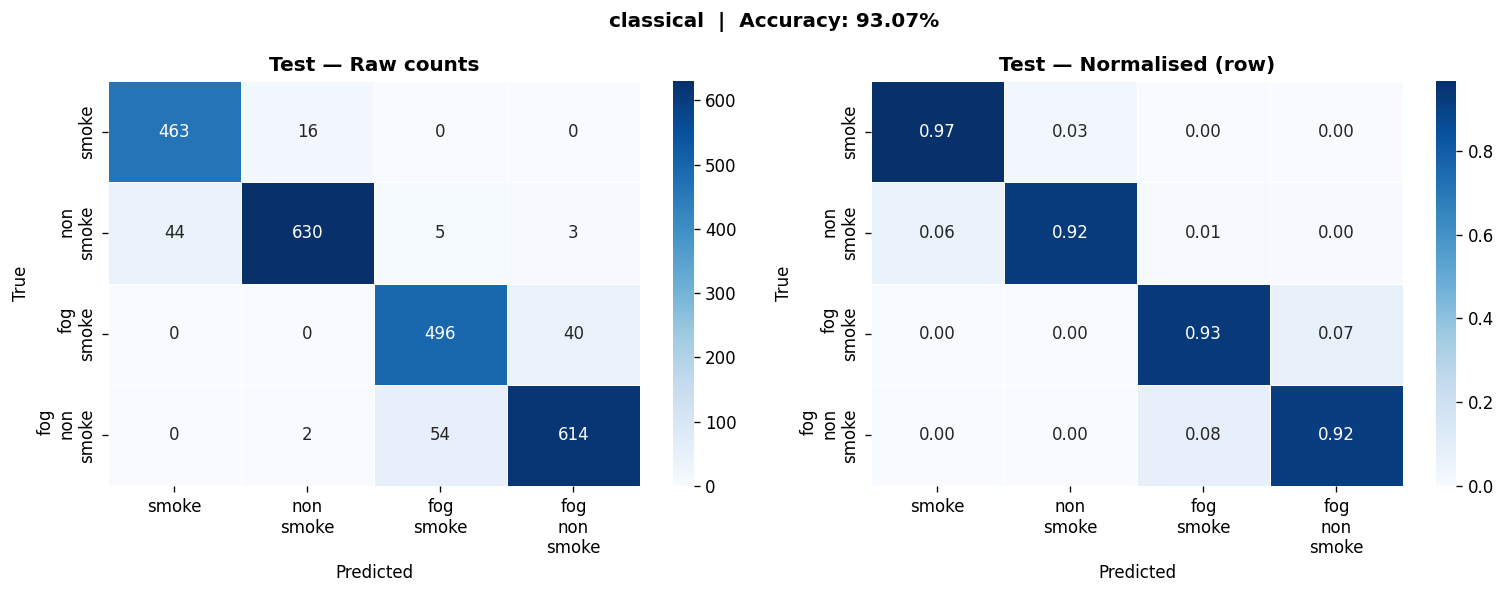

Saved: classical_confusion_test.png


In [18]:
def evaluate_model(model, X, y_true, class_names, split_name='Test', save_prefix='classical'):

    y_pred = model.predict(X)
    acc    = accuracy_score(y_true, y_pred)

    print(f'\n{'='*55}')
    print(f'  {split_name} Results  --  {save_prefix}')
    print(f'{'='*55}')
    print(f'  Accuracy: {acc*100:.2f}%\n')
    print(classification_report(
        y_true, y_pred,
        target_names=[c.replace('_', ' ') for c in class_names]))

    # Raw + normalised confusion matrices side by side
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels  = [c.replace('_', '\n') for c in class_names]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, title in zip(
            axes,
            [cm, cm_norm],
            ['d', '.2f'],
            ['Raw counts', 'Normalised (row)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, linecolor='white')
        ax.set_title(f'{split_name} — {title}', fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')

    plt.suptitle(f'{save_prefix}  |  Accuracy: {acc*100:.2f}%', fontweight='bold')
    plt.tight_layout()
    fname = f'{save_prefix}_confusion_{split_name.lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    rd = classification_report(y_true, y_pred,
                                target_names=class_names, output_dict=True)
    return {'accuracy': acc, 'y_pred': y_pred,
            'report': pd.DataFrame(rd).T.round(3)}


val_results  = evaluate_model(pipeline_clf, X_val,  y_val,  CLASS_NAMES, 'Validation')
test_results = evaluate_model(pipeline_clf, X_test, y_test, CLASS_NAMES, 'Test')

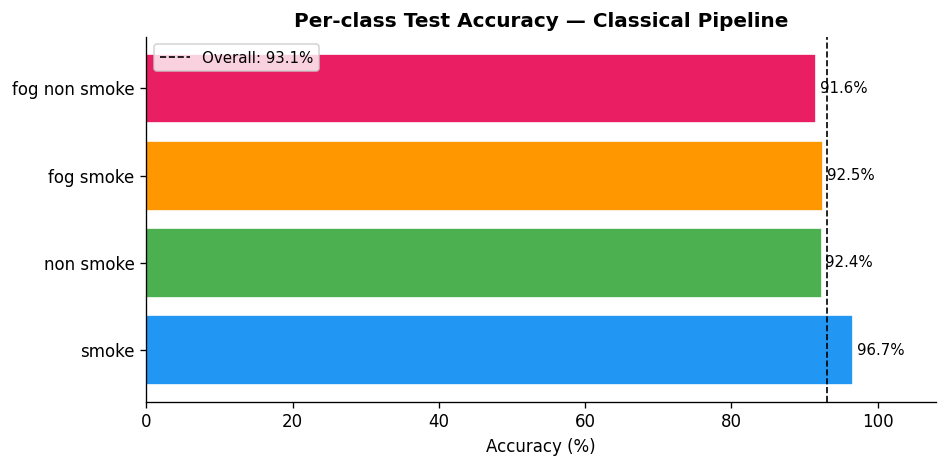

In [19]:
# Per-class accuracy bar chart
y_pred = test_results['y_pred']
per_class = {}
for i, name in enumerate(CLASS_NAMES):
    mask = y_test == i
    per_class[name] = accuracy_score(y_test[mask], y_pred[mask])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh([c.replace('_', ' ') for c in CLASS_NAMES],
               [per_class[c] * 100 for c in CLASS_NAMES],
               color=PALETTE, edgecolor='white')
ax.axvline(test_results['accuracy'] * 100, color='black', linestyle='--',
           linewidth=1, label=f'Overall: {test_results["accuracy"]*100:.1f}%')
ax.set_xlabel('Accuracy (%)')
ax.set_xlim(0, 108)
ax.set_title('Per-class Test Accuracy — Classical Pipeline', fontweight='bold')
ax.legend(fontsize=9)
for bar, name in zip(bars, CLASS_NAMES):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{per_class[name]*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('classical_per_class_accuracy.png', bbox_inches='tight')
plt.show()

## 10. Shared Utilities for M2 & M3

Copy the cell below into part 2 and 3 notebooks for consistency if you want.

In [20]:
# SHARED UTILITIES

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Constants
SEED        = 42
IMG_SIZE    = (128, 128)
CLASS_NAMES = ['smoke', 'non_smoke', 'fog_smoke', 'fog_non_smoke']
NUM_CLASSES = 4
PALETTE     = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
DATASET_ROOT = Path('/content/IIITDMJ_Smoke/IIITDMJ_Smoke')

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


def preprocess_image(img_path, img_size=IMG_SIZE, keep_color=True):
    #Load, resize, normalise. Returns float32 in [0,1].
    img = imread(img_path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = resize(img, img_size, anti_aliasing=True, mode='reflect')
    if not keep_color:
        img = rgb2gray(img)
    return img.astype(np.float32)


def evaluate_and_plot(model_name, y_true, y_pred, class_names=CLASS_NAMES):

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f'[{model_name}] Accuracy: {acc*100:.2f}%')
    print(classification_report(
        y_true, y_pred,
        target_names=[c.replace('_', ' ') for c in class_names]))

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels  = [c.replace('_', '\n') for c in class_names]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, title in zip(
            axes, [cm, cm_norm], ['d', '.2f'],
            ['Raw counts', 'Normalised (row)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, linecolor='white')
        ax.set_title(f'{model_name} — {title}', fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'confusion_{model_name.replace(" ", "_")}.png', bbox_inches='tight')
    plt.show()

    rd = classification_report(y_true, y_pred,
                                target_names=class_names, output_dict=True)
    return {
        'accuracy'           : acc,
        'per_class_precision': {c: rd[c]['precision'] for c in class_names},
        'per_class_recall'   : {c: rd[c]['recall']    for c in class_names},
        'per_class_f1'       : {c: rd[c]['f1-score']  for c in class_names},
    }

print("done")

done
